In [ ]:
from configPy import DirManager, EnvManager, Config
import pandas as pd
import matplotlib.pyplot as plt

file_dir = Config.get_dir_files()
planilhas = file_dir["planilhas"]

# arquivo de interesse

orcamento = planilhas.get_any("planilha_Dados - Orçamento.csv")


In [3]:
df = pd.read_csv(orcamento)

In [7]:
df.head()

,Centro de Responsabilidade,Cod centro,Nome conta 1º nível,Cod conta 1º nível,Nome conta 2º nível,Cod conta 2º nível,Nome conta 3º nível,Cod conta 3º nível,Ano,Mês,nº mês,Realizado
0,Mirante,10113,Despesa,1,Despesas Correntes,11,Pessoal e Encargos,111,2022,JANEIRO,1,278804.36
1,Mirante,10113,Despesa,1,Despesas Correntes,11,Ocupação e Utilidades,115,2022,JANEIRO,1,11159.69
2,Mirante,10113,Despesa,1,Despesas Correntes,11,Material de Consumo,114,2022,JANEIRO,1,20196.21
3,Mirante,10113,Despesa,1,Despesas Correntes,11,Transportes e Viagens,111,2022,JANEIRO,1,14646.09
4,Mirante,10113,Despesa,1,Despesas Correntes,11,Serviços de terceiros,117,2022,JANEIRO,1,33010.87


## Nível de receita e despesa por Centro de Custo

In [ ]:
# Identificar todos os centros
# Criar data frame filtrando as linhas com o centro desejado
# Incluir apenas os dados de interesse (Nome conta 1° nível, Realizado)

In [6]:
# valore únicos dos centros
centros = df['Centro de Responsabilidade'].unique()
centros

<StringArray>
['Mirante', 'Sol Leste', 'Vitória']
Length: 3, dtype: str

In [39]:
df_agrupamento = df.groupby(["Centro de Responsabilidade", "Nome conta 1º nível"])["Realizado"].sum().unstack().abs()
print(df_agrupamento)

Nome conta 1º nível            Despesa     Receita
Centro de Responsabilidade                        
Mirante                     6571299.17  8762190.58
Sol Leste                   1375208.01  7925520.62
Vitória                     8077648.37  7669373.69


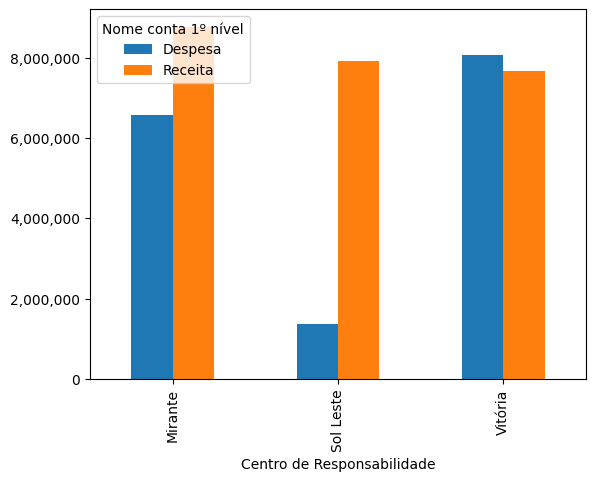

In [43]:
import matplotlib.ticker as ticker
ax = df_agrupamento.plot.bar()

ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.show()

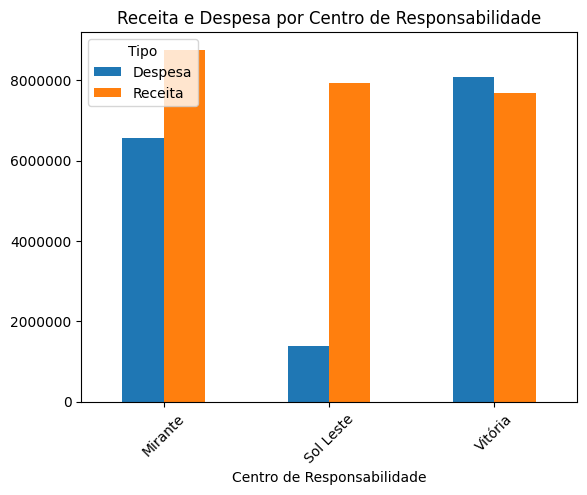

In [44]:
import matplotlib.pyplot as plt

df_agrupamento.plot.bar()

plt.title("Receita e Despesa por Centro de Responsabilidade")
plt.xlabel("Centro de Responsabilidade")

plt.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)
plt.legend(title="Tipo")

plt.show()

## Lucro por filial

In [45]:
lucro_por_filial = df_agrupamento["Receita"] - df_agrupamento["Despesa"]
lucro_por_filial

Centro de Responsabilidade
Mirante      2190891.41
Sol Leste    6550312.61
Vitória      -408274.68
dtype: float64

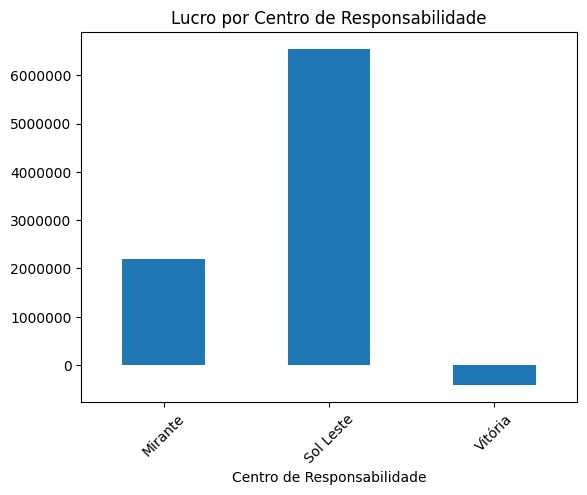

In [49]:
lucro_por_filial.plot.bar()

plt.title("Lucro por Centro de Responsabilidade")
plt.xlabel("Centro de Responsabilidade")


plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.show()

## Despesa por conta

In [53]:
df_de_despesa = df[df["Nome conta 1º nível"] == "Despesa"]
df_despesa_por_conta = df_de_despesa.groupby("Nome conta 3º nível")["Realizado"].sum()
df_despesa_por_conta

Nome conta 3º nível
Impostos e taxas          745327.89
Investimentos            3496171.89
Material de Consumo       594953.32
Ocupação e Utilidades     363427.55
Outras despesas           182365.68
Pessoal e Encargos       9297066.37
Serviços de terceiros     953086.94
Transportes e Viagens     391755.91
Name: Realizado, dtype: float64

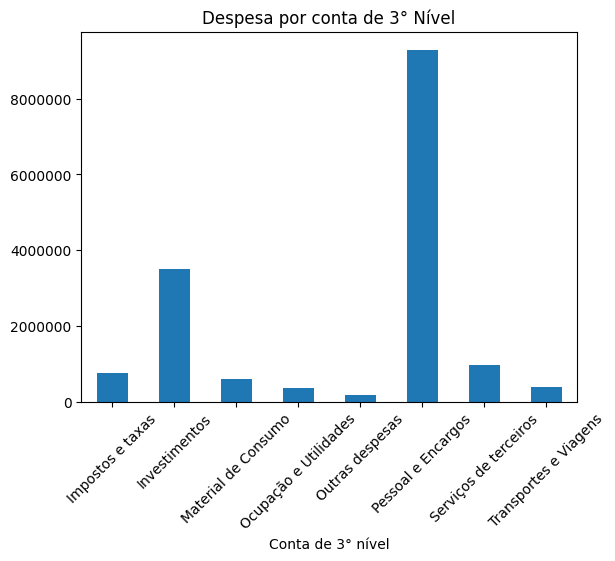

In [55]:
df_despesa_por_conta.plot.bar()

plt.title("Despesa por conta de 3° Nível")
plt.xlabel("Conta de 3° nível")


plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)

plt.show()

## Despesa e receita por conta 2° nível

In [59]:
df_receita_despesa_conta = df.groupby(["Nome conta 1º nível", "Nome conta 2º nível"])["Realizado"].sum().unstack()
df_receita_despesa_conta

Nome conta 2º nível,Despesas Correntes,Despesas de Capital,Receitas Correntes
Nome conta 1º nível,,,
Despesa,12527983.66,3496171.89,NaN
Receita,NaN,NaN,24357084.89


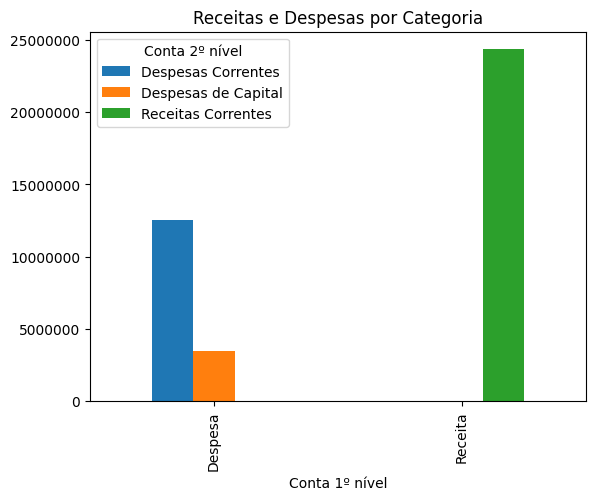

In [61]:
df_plot = df_receita_despesa_conta.fillna(0)

df_plot.plot.bar()

plt.title("Receitas e Despesas por Categoria")
plt.xlabel("Conta 1º nível")

plt.ticklabel_format(style='plain', axis='y')
plt.legend(title="Conta 2º nível")

plt.show()

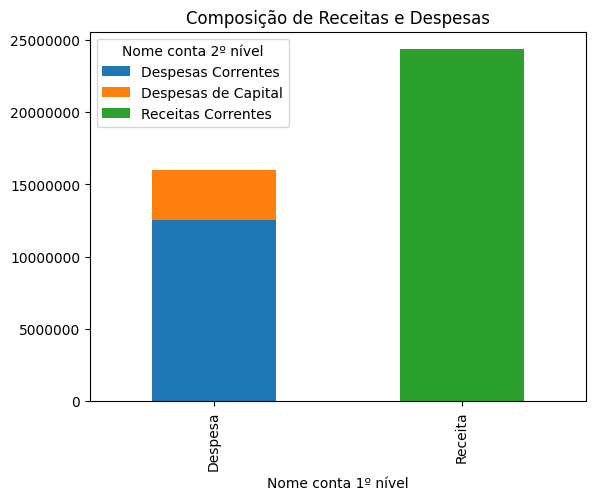

In [63]:
df_plot.plot.bar(stacked=True)

plt.title("Composição de Receitas e Despesas")
plt.ticklabel_format(style='plain', axis='y')

plt.show()

In [65]:
mercado = planilhas.get_any("planilha_Dados - Mercado.csv")

In [79]:
df_mercado = pd.read_csv(mercado)
df_mercado.head()

,Centro de Responsabilidade,Cod centro,Cod conta 1º nível,Nome conta 2º nível,Cod conta 2º nível,Nome conta 3º nível,Cod conta 3º nível,Motivo do contrato,Vendedor,Data da Admissão,...,nº Mês,Receitas de Serviço (contratos),Foma de Pagamento,Cadastro de Reclamação,Reclamação Cadastrada,Retorno à reclamação,Satifação com o Produto,NPS,Tipo de Cliente,NPS2
0,Mirante,10113.0,2.0,Receitas Correntes,21.0,Receitas de serviços,211.0,Demanda,Julia Roberts,2019-07-03,...,1.0,26805.55,Tranferencia bancária,NaN,NaN,NaN,Sim,7,NaN,Neutro
1,Mirante,10113.0,2.0,Receitas Correntes,21.0,Receitas de serviços,211.0,Prospecção,Keanu Reeves,2019-12-03,...,1.0,42888.87,Tranferencia bancária,Sim,Qualidade do Serviço/produto,Sim,Não,1,Novo Cliente,Detrator
2,Mirante,10113.0,2.0,Receitas Correntes,21.0,Receitas de serviços,211.0,Prospecção,Kevin Costner,2018-10-03,...,1.0,91138.86,PIX,NaN,NaN,NaN,Sim,7,Novo Cliente,Neutro
3,Mirante,10113.0,2.0,Receitas Correntes,21.0,Receitas de serviços,211.0,Demanda,Mel Gibson,2019-11-02,...,1.0,139388.84,Tranferencia bancária,NaN,NaN,NaN,Sim,6,NaN,Detrator
4,Mirante,10113.0,2.0,Receitas Correntes,21.0,Receitas de serviços,211.0,Prospecção,Meryl Streep,2017-03-01,...,1.0,-,NaN,Sim,Qualidade do Serviço/produto,Não,Não,5,Novo Cliente,Detrator


## Motivo de contrato por filial

In [81]:
df_contrato_por_centro = df_mercado.groupby(["Centro de Responsabilidade", "Motivo do contrato"]).size().unstack(fill_value=0)
print(df_contrato_por_centro)

Motivo do contrato          Demanda  Prospecção
Centro de Responsabilidade                     
Mirante                          48          48
Sol Leste                        12          82
Vitória                          34          18


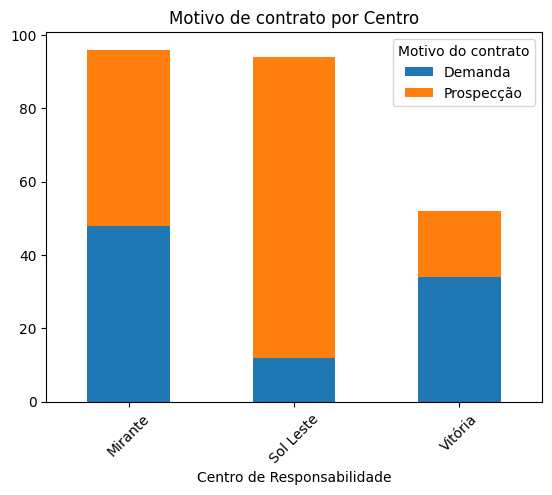

In [83]:
df_contrato_por_centro.plot(kind="bar", stacked=True)


plt.title("Motivo de contrato por Centro")
plt.xticks(rotation=45)

plt.show()

## Receitas por motivo de contrato

In [86]:
print(df.columns)

Index(['Centro de Responsabilidade', 'Cod centro', 'Nome conta 1º nível',
       'Cod conta 1º nível', 'Nome conta 2º nível', 'Cod conta 2º nível',
       'Nome conta 3º nível', 'Cod conta 3º nível', 'Ano', 'Mês', 'nº mês',
       'Realizado'],
      dtype='str')


In [87]:
db_receita_numerica = df_mercado[pd.to_numeric(df_mercado["Receitas de Serviço (contratos)"], errors="coerce").notna()]

In [90]:
db_receita_numerica["Receitas de Serviço (contratos)"] = pd.to_numeric(
    db_receita_numerica["Receitas de Serviço (contratos)"],
    errors="coerce"
)
df_group_receita_contrato = db_receita_numerica.groupby("Motivo do contrato")["Receitas de Serviço (contratos)"].sum()
df_group_receita_contrato

Motivo do contrato
Demanda       10128375.66
Prospecção    14228709.23
Name: Receitas de Serviço (contratos), dtype: float64

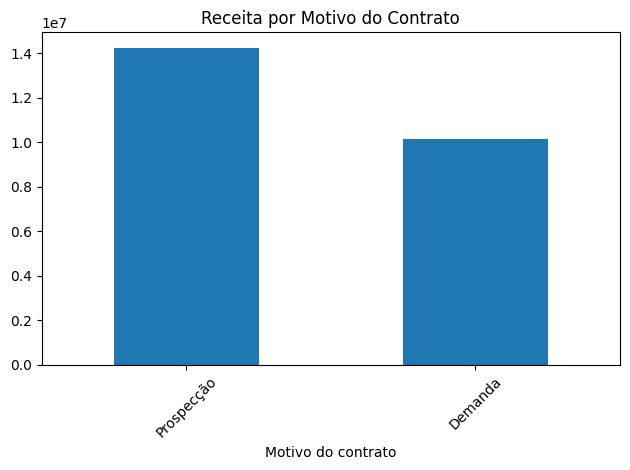

In [92]:
import matplotlib.pyplot as plt

df_plot = df_group_receita_contrato.sort_values(ascending=False)

df_plot.plot(kind="bar")

plt.xlabel("Motivo do contrato")
plt.title("Receita por Motivo do Contrato")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Satisfação com serviço por filial

In [75]:

df_group = (
    df_mercado
    .groupby(["Centro de Responsabilidade", "Satifação com o Produto"])
    .size()
    .unstack(fill_value=0)
)
df_group = df_group.drop(columns="-")

In [76]:
print(df_group)

Satifação com o Produto     Não  Sim
Centro de Responsabilidade          
Mirante                      34   62
Sol Leste                    28   66
Vitória                      12   36


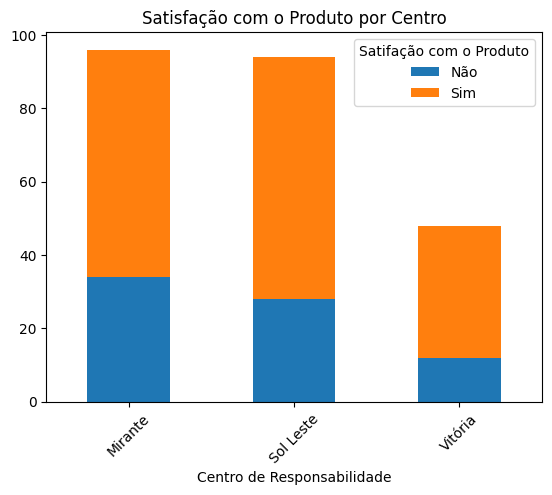

In [78]:
df_group.plot(kind="bar", stacked=True)


plt.title("Satisfação com o Produto por Centro")
plt.xticks(rotation=45)

plt.show()

## NPS

In [94]:
df_nps = df_mercado[pd.to_numeric(df_mercado["NPS"], errors="coerce").notna()]

In [97]:
df_nps["NPS"] = pd.to_numeric(df_nps["NPS"], errors="coerce")

df_nps_mean_center = df_nps.groupby("Centro de Responsabilidade")["NPS"].mean()
df_nps_mean_center

Centro de Responsabilidade
Mirante      6.645833
Sol Leste    6.170213
Vitória      6.750000
Name: NPS, dtype: float64

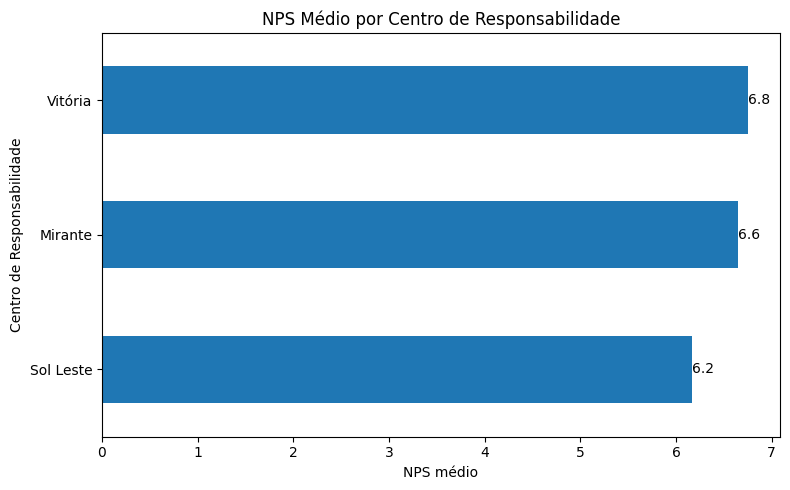

In [99]:
df_plot = df_nps_mean_center.sort_values()

plt.figure(figsize=(8,5))

df_plot.plot(kind="barh")

plt.xlabel("NPS médio")
plt.title("NPS Médio por Centro de Responsabilidade")

for i, v in enumerate(df_plot):
    plt.text(v, i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.show()